In [9]:
!python main.py -m DeepCNN --layers 16 pool 32 pool 64 pool 128 pool 256 pool --transform aug --epoch 100 --batch-size 16

DeepCNN(
  (conv): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Linear(in_features=6400, out_features=2, bias=True)
)
There are 405410 parameters in this model
Use aug transformer for training

Epoch 1 / 100
train Accur


100%|██████████| 38/38 [00:13<00:00,  2.72it/s]

100%|██████████| 5/5 [00:00<00:00,  5.57it/s]

100%|██████████| 38/38 [00:08<00:00,  4.64it/s]

100%|██████████| 5/5 [00:00<00:00, 12.85it/s]

100%|██████████| 38/38 [00:10<00:00,  3.59it/s]

100%|██████████| 5/5 [00:00<00:00,  5.41it/s]

100%|██████████| 38/38 [00:13<00:00,  2.80it/s]

100%|██████████| 5/5 [00:00<00:00,  5.63it/s]

100%|██████████| 38/38 [00:12<00:00,  3.04it/s]

100%|██████████| 5/5 [00:00<00:00,  5.97it/s]

100%|██████████| 38/38 [00:13<00:00,  2.88it/s]

100%|██████████| 5/5 [00:00<00:00,  5.80it/s]

100%|██████████| 38/38 [00:13<00:00,  2.74it/s]

100%|██████████| 5/5 [00:00<00:00,  5.41it/s]

100%|██████████| 38/38 [00:13<00:00,  2.78it/s]

100%|██████████| 5/5 [00:00<00:00,  5.92it/s]

100%|██████████| 38/38 [00:13<00:00,  2.83it/s]

100%|██████████| 5/5 [00:00<00:00, 12.32it/s]

100%|██████████| 38/38 [00:12<00:00,  2.97it/s]

100%|██████████| 5/5 [00:00<00:00,  5.78it/s]

100%|██████████| 38/38 [00:13<00:00,  2

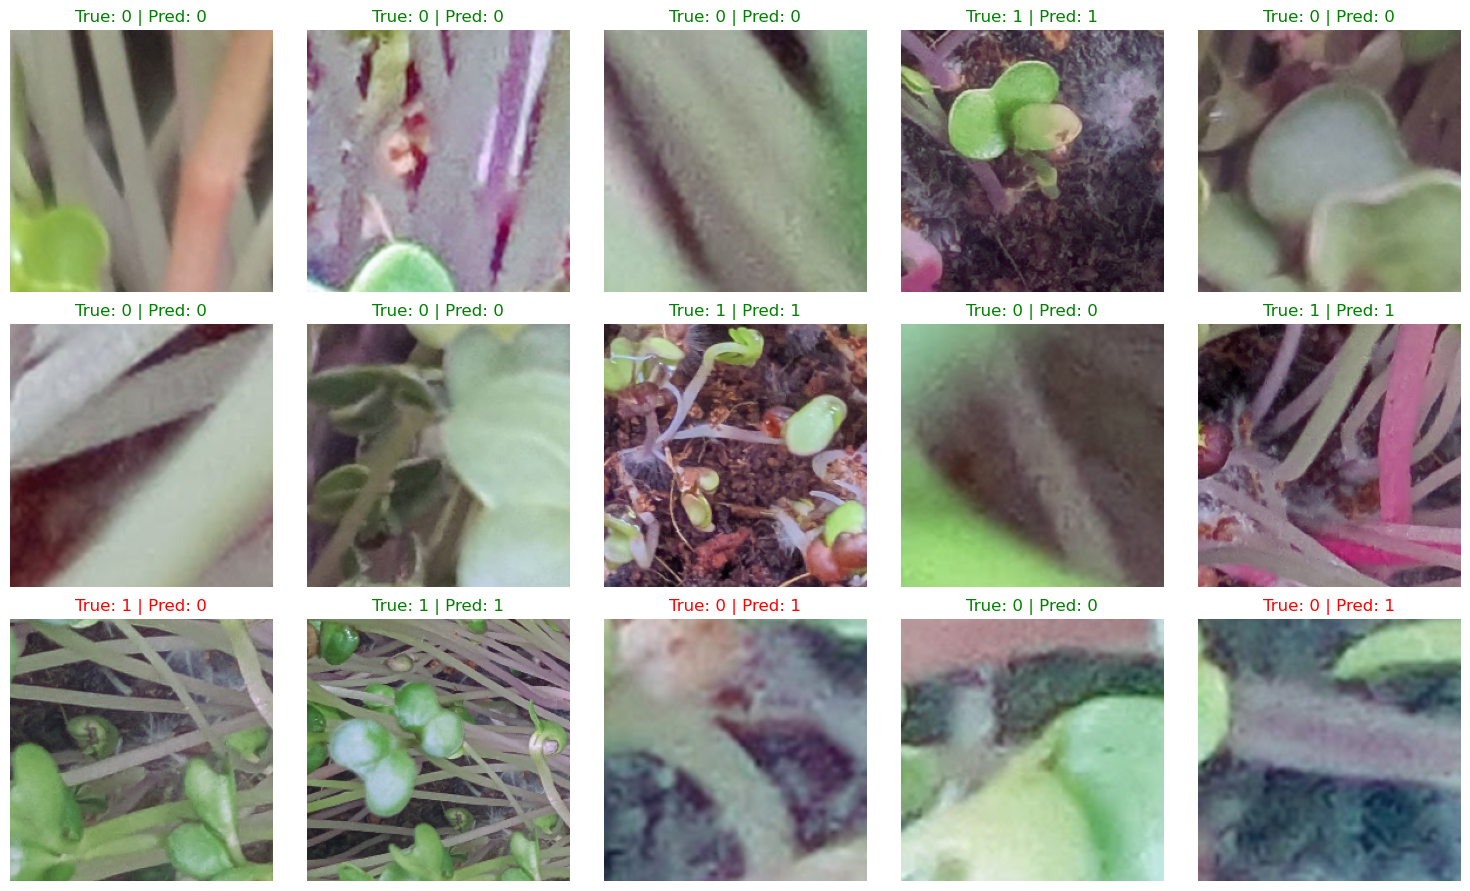

In [5]:
import torch
from model import DeepCNN, norm_transformer
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import os 

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

# Load DeepCNN model
net = model.DeepCNN(arr=[16, "pool", 32, "pool", 64, "pool", 128, "pool", 256, "pool"])
net.load_state_dict(torch.load("best_DeepCNN.pt"))
net.eval()
if use_cuda:
    net = net.to(device)

# Load test CSV
test_df = pd.read_csv("test.csv")

# Randomly pick 15 images
samples = test_df.sample(n=15, random_state=42).reset_index(drop=True)

# Plot 15 images
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for i, row in samples.iterrows():
    img = Image.open(row["path"])

    input_tensor = norm_transformer(img).unsqueeze(0)
    if use_cuda:
        input_tensor = input_tensor.to(device)

    with torch.no_grad():
        output = net(input_tensor)
        _, pred = torch.max(output, 1)

    axes[i].imshow(img)
    color = 'green' if pred.item() == row["label"] else 'red'
    axes[i].set_title(f"True: {row['label']} | Pred: {pred.item()}", color=color)
    axes[i].axis('off')

plt.tight_layout()
plt.show()


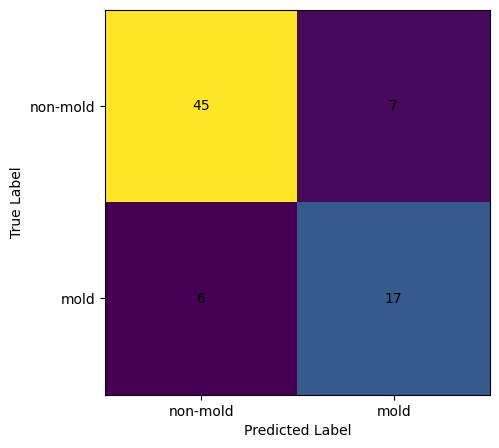

Class 0 accuracy: 0.8654
Class 1 accuracy: 0.7391


In [1]:
import torch
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import loader
import model

use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

# Load DeepCNN model
net = model.DeepCNN(arr=[16, "pool", 32, "pool", 64, "pool", 128, "pool", 256, "pool"])
net.load_state_dict(torch.load("best_DeepCNN.pt"))
net.eval()

_, _, testloader = loader.get_data_loader(
    model.aug_transformer,
    model.norm_transformer,
    model.norm_transformer,
    batch_size=16
)

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = net(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(5,5))
im = ax.imshow(cm)

# Add labels
classes = ["non-mold", "mold"]
ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add text in cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.show()

# Compute per-class accuracy
class_0_acc = cm[0,0] / cm[0].sum()
class_1_acc = cm[1,1] / cm[1].sum()
print(f"Class 0 accuracy: {class_0_acc:.4f}")
print(f"Class 1 accuracy: {class_1_acc:.4f}")